In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd
from pathlib import Path
from helper import *

In [62]:
TEST_DIR = True

In [63]:
# CONFIG
data_dir_path = "/B2 Data/" # Change this between notebooks

TEST_DIR = False

csv_dict = {
"3": ["T0034.CSV", "T0035.CSV", "T0036.CSV"],
"2.5": ["T0037.CSV", "T0038.CSV", "T0039.CSV"],
"2": ["T0040.CSV", "T0041.CSV", "T0042.CSV"],
"1.5": ["T0043.CSV", "T0044.CSV", "T0045.CSV"],
# "1": ["T0046.CSV"]
"1": ["T0046.CSV", "T0047.CSV", "T0048.CSV"],
"0.5": ["T0049.CSV", "T0050.CSV", "T0051.CSV"]
}

In [64]:
# DIR CONFIG
base_dir_path = str(Path.cwd())
DATA_DIR = base_dir_path + data_dir_path

if TEST_DIR == False:
    print("Test Path: ", DATA_DIR + "T0035.CSV")
    df = pd.read_csv(DATA_DIR + "T0035.CSV", skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
    print("Data frame loaded!")

Test Path:  /Users/jacobbalek/Documents/The Ohio State University/PHYS 5700 Adv Physics Lab/PHYS 5700 Adv Physics Lab Spring 2026/Earths Field NMR/B2 Data/T0035.CSV
Data frame loaded!


Look at a singular file

In [65]:
test_csv = "T0035.CSV"
df_test = pd.read_csv(DATA_DIR + test_csv, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])
df_test = df_test.apply(pd.to_numeric, errors='coerce') # Foce data types from strings to numbers

# Look at the df
x = df_test["CH1"].to_numpy()
y = df_test["CH2"].to_numpy()
t = df_test["TIME"].to_numpy()

x_test = df_test["CH1 Peak Detect"].to_numpy()

# Verify
print(df_test.dtypes)
print(df_test.head())

TIME               float64
CH1                float64
CH1 Peak Detect    float64
CH2                float64
CH2 Peak Detect    float64
dtype: object
       TIME           CH1  CH1 Peak Detect    CH2  CH2 Peak Detect
0       NaN           NaN              NaN    NaN              NaN
1 -0.229984  6.675720e-09            0.008  0.006            0.010
2 -0.229952  6.675720e-09           -0.016  0.002           -0.002
3 -0.229920  6.675720e-09            0.008  0.006            0.014
4 -0.229888  6.675720e-09           -0.016  0.006           -0.006


In [66]:
# Find index where t = 0
idx = find_closest_index(df_test, delay = 256, column_name = 'TIME')
print(f"The index closest to 0 is: {idx}")

print(f"With a value of : {df_test["CH2"].iloc[idx + 250]}")

The index closest to 0 is: 7188
With a value of : 0.438


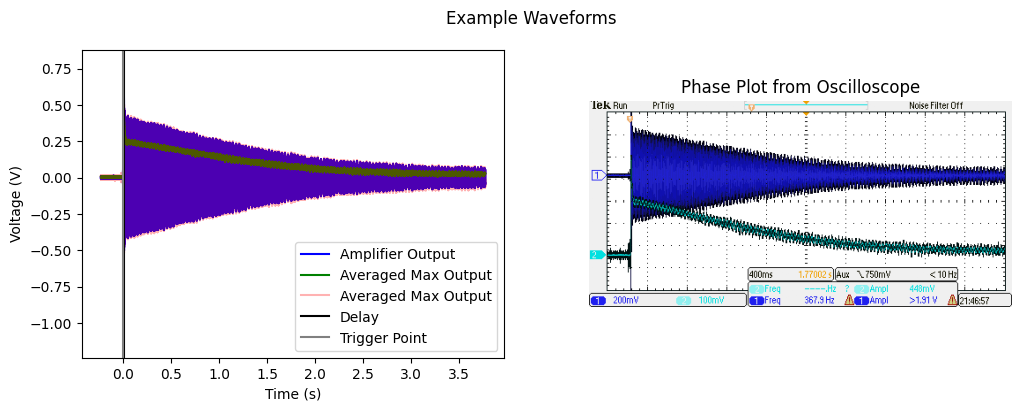

In [67]:
# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Example Waveforms')

# Plot CSV Data on ax1

# Plot CH1 (Signal)
ax1.plot(t, x, label='Amplifier Output', 
                    color='blue')
# Plot CH2 (Averaged Max)
ax1.plot(t, y, label='Averaged Max Output', 
                    color='green')

# Plot CH1 Peak Detect
ax1.plot(t, x_test, label='Averaged Max Output', 
                    color='red', alpha = 0.3)

# Plot Added Delay
ax1.axvline(x=t[idx + 256], label="Delay", color = "black")

# Plot Trigger Point
ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")
ax1.legend()




# Plot Image on ax2
img = plt.imread(DATA_DIR + "T0035.png")
ax2.imshow(img)
ax2.set_title("Phase Plot from Oscilloscope")
ax2.axis('off')

plt.show()

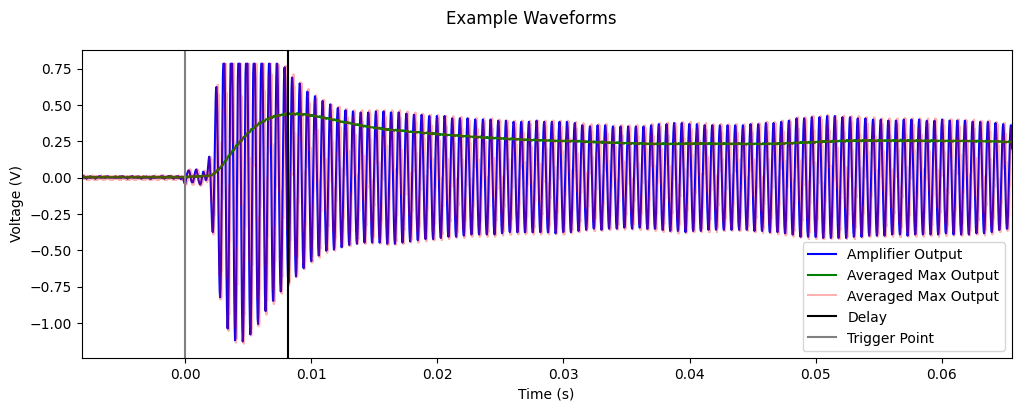

In [68]:
# Plot
fig2, ax1 = plt.subplots(1, 1, figsize=(12, 4))
fig2.suptitle('Example Waveforms')

# Plot CSV Data on ax1

# Plot CH1 (Signal)
ax1.plot(t, x, label='Amplifier Output', 
                    color='blue')
# Plot CH2 (Averaged Max)
ax1.plot(t, y, label='Averaged Max Output', 
                    color='green')

# Plot CH1 Peak Detect
ax1.plot(t, x_test, label='Averaged Max Output', 
                    color='red', alpha = 0.3)

# Plot Added Delay
ax1.axvline(x=t[idx + 256], label="Delay", color = "black")

# Plot Trigger Point
ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")
ax1.legend()
ax1.set_xlim(t[idx - 256], t[idx + 256 * 8])
ax1.set_xlim(t[idx - 256], t[idx + 256 * 8])

plt.show()

## Look at Frequencies

Text(0.5, 0, 'Time (s)')

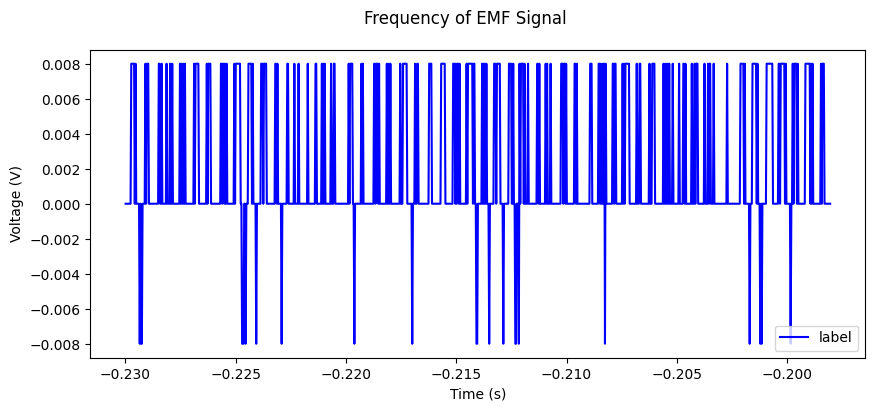

In [69]:
end = 1000

# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

ax1.plot(t[:end], x[:end], label='label', 
                    color='blue')
# ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.legend()
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

In [70]:
start = idx # Set start index at trigger point
end = start + 1000 # Set end index

t_subset = t[start:end]
x_subset = x[start:end]

# For initial guess, do FFT
y_fft = np.fft.rfft(x_subset)
# print(y_fft)
y_fft = np.fft.rfft(x_subset)
freqs = np.fft.rfftfreq(len(t_subset), d=(t_subset[1] - t_subset[0]))
fft_frequency = freqs[np.argmax(np.abs(y_fft))]
print(f"Fast Fourier Transform Frequency: {fft_frequency:.2f} Hz")


# Fit to a sine model
freq = fft_frequency * 2 * np.pi # TODO: Figure out why this needs to be multiplied by 2pi
def sine_fcn(B, x):
    return B[0] * np.sin(freq * x + B[1])
sine_model = odr.Model(sine_fcn)

mydata = odr.RealData(t_subset, x_subset)

sol = odr.ODR(mydata, sine_model, beta0=[0.4, 0])
myoutput = sol.run()
# myoutput.pprint()

Fast Fourier Transform Frequency: 1656.25 Hz


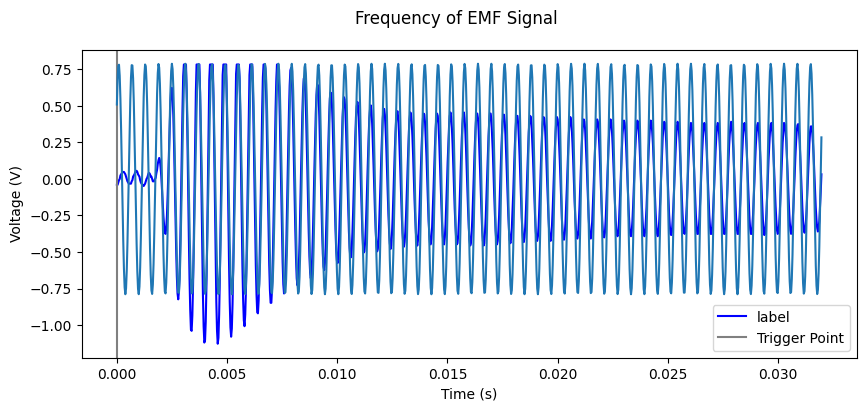

In [71]:
# Plot to see if the FFT frequency is close
fig, ax1 = plt.subplots(1, 1, figsize=(10, 4))
fig.suptitle('Frequency of EMF Signal')

ax1.plot(t[start:end], x[start:end], label='label', 
                    color='blue')
ax1.axvline(x=t[idx], label="Trigger Point", color = "gray")
ax1.legend()
ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Time (s)")

# Plot fitted sine wave
fitted_x = sine_fcn(myoutput.beta, t_subset)
ax1.plot(t_subset, fitted_x)

## Plot Amplitude of Signal Against Current

In [72]:
(ch1, ch2) = max_at_trigger_delay(df_test, delay = 256)
print(ch1, ch2)

(ch1, ch2) = max_at_trigger(df_test, delay = 256)
print(ch1, ch2)

-0.728 0.438
-0.04 0.006


In [73]:
total_points = []
ch1_avg_points = []
ch1_std_points = []
ch2_avg_points = []
ch2_std_points = []

for m_time, paths in csv_dict.items():
    # Look at each of the three CSV's
    CH2_points = []
    CH1_points = []
    for i in range(3):
        single_csv_path = paths[i]
        csv_path = DATA_DIR + single_csv_path

        # Read csv
        df = pd.read_csv(csv_path, skiprows = 15, names=['TIME','CH1','CH1 Peak Detect','CH2','CH2 Peak Detect'])

        # Foce data types from strings to numbers
        df = df.apply(pd.to_numeric, errors='coerce')

        # Get CH2 value
        (CH1, CH2) = max_at_trigger_avg(df, fft_frequency, delay = 1000) # Try increasing delay? From 256 to 500 (1000 works)

        # Add CH2 value to plotting points
        total_points.append((m_time, CH2))
        CH1_points.append(CH1)
        CH2_points.append(CH2)

    # Save std and average
    ch1_std_points.append((m_time, np.std(CH1_points)))
    ch1_avg_points.append((m_time, np.mean(CH1_points)))
    ch2_std_points.append((m_time, np.std(CH2_points)))
    ch2_avg_points.append((m_time, np.mean(CH2_points)))


    # Try taking max value of a range, which includes one complete cycle (abs(df["CH2"][int((fft_frequency / 2) * .00032)])
    pass

In [74]:
print(ch2_avg_points)

[('3', np.float64(0.25933333333333336)), ('2.5', np.float64(0.21666666666666667)), ('2', np.float64(0.15533333333333332)), ('1.5', np.float64(0.12866666666666668)), ('1', np.float64(0.078)), ('0.5', np.float64(0.057999999999999996))]


In [75]:
# Use standard deviation to estimate uncertainty
y_uncerts = []
print("Time, STD, STD with Trace")
for time, std in ch2_std_points:
    error_quad = np.sqrt(.008**2 + std**2)
    y_uncerts.append(error_quad)
    print(time, std**2, error_quad)

# Add the errors in quadriature

Time, STD, STD with Trace
3 4.622222222222231e-05 0.010498677165349085
2.5 5.688888888888898e-05 0.010994948334980431
2 2.4888888888888933e-05 0.009428090415820637
1.5 2.4888888888888933e-05 0.009428090415820637
1 7.466666666666662e-05 0.011775681155103792
0.5 1.066666666666667e-05 0.008640987597877148


In [76]:
# Unpack data_points
ch1_x_vals = []
ch1_y_vals = []
for tuple in ch1_avg_points:
    time = eval(tuple[0])
    voltage = tuple[1]
    ch1_x_vals.append(time)
    ch1_y_vals.append(voltage)

# Turn into nparrays
ch1_x_vals = np.array(ch1_x_vals)
ch1_y_vals = np.array(ch1_y_vals)

# Unpack data_points
ch2_x_vals = []
ch2_y_vals = []
for tuple in ch2_avg_points:
    time = eval(tuple[0])
    voltage = tuple[1]
    ch2_x_vals.append(time)
    ch2_y_vals.append(voltage)

# Turn into nparrays
ch2_x_vals = np.array(ch2_x_vals)
ch2_y_vals = np.array(ch2_y_vals)

In [77]:
# Fit

# Use t=13 point as M0


# Plot ln(M_0) = ln(M_0 - M(t)) + 1/T_1 t
def linear_fcn(B, x): # B[0] = T_1, B[1] = M_0
    return B[0] * x + B[1]
model = odr.Model(linear_fcn)

ch1_data = odr.RealData(ch1_x_vals, ch1_y_vals, sy = y_uncerts)

ch2_data = odr.RealData(ch2_x_vals, ch2_y_vals, sy = y_uncerts)

ch1_sol = odr.ODR(ch1_data, model, beta0=[0, 0])
ch2_sol = odr.ODR(ch2_data, model, beta0=[0, 0])

ch1_output = ch1_sol.run()
ch2_output = ch2_sol.run()

print("CH1 Fitting:")
ch1_output.pprint()

print("CH2 Fitting:")
ch2_output.pprint()

CH1 Fitting:
Beta: [ 0.13399848 -0.00826598]
Beta Std Error: [0.00737704 0.01434658]
Beta Covariance: [[ 0.00417806 -0.00731065]
 [-0.00731065  0.01580179]]
Residual Variance: 0.01302538032767172
Inverse Condition #: 0.17290122573465883
Reason(s) for Halting:
  Sum of squares convergence
CH2 Fitting:
Beta: [0.08420729 0.00197907]
Beta Std Error: [0.00554162 0.01076968]
Beta Covariance: [[ 0.00167282 -0.0029263 ]
 [-0.0029263   0.00631804]]
Residual Variance: 0.01835790153191494
Inverse Condition #: 0.1726191506058338
Reason(s) for Halting:
  Sum of squares convergence


In [78]:
# Look at pngs and see what slope we estimate
eyeball_vals = [0.46, 0.4, 0.26, 0.25, 0.2, 0.06]

eyeball_data = odr.RealData(ch1_x_vals, eyeball_vals)
eyeball_sol = odr.ODR(eyeball_data, model, beta0=[0, 0])
eyeball_output = eyeball_sol.run()

<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\c'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_36558/2447883361.py:43: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2_{{red}}$: {ch1_red_chi_sq:.2f}"
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_36558/2447883361.py:46: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2_{{red}}$: {ch2_red_chi_sq:.2f}"


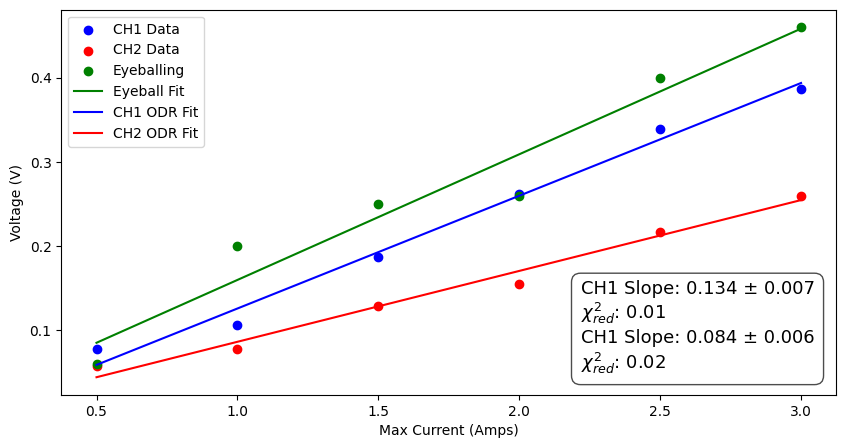

In [79]:
# Plot
fig3, ax1 = plt.subplots(1, 1, figsize=(10, 5))

ax1.scatter(ch1_x_vals, ch1_y_vals, label='CH1 Data', color='blue')
ax1.scatter(ch2_x_vals, ch2_y_vals, label='CH2 Data', color='red')

## EYEBALL ##
ax1.scatter(ch2_x_vals, eyeball_vals, label='Eyeballing', color='green')
ch2_x_fit = np.linspace(ch2_x_vals.min(), ch2_x_vals.max(), 100)
eyeball_fit = linear_fcn(eyeball_output.beta, ch2_x_fit)
ax1.plot(ch2_x_fit, eyeball_fit, color='green', label='Eyeball Fit') # CH1 Fit
#############

# plt.errorbar(x_vals, y_vals, 
#              # xerr=x_uncerts, 
#              yerr=y_uncerts,
#              fmt='o', label='Data', capsize=3, markersize=4)

# ax1.plot(x_fit, y_fit, color='red', label='ODR Fit')

ch1_x_fit = np.linspace(ch1_x_vals.min(), ch1_x_vals.max(), 100)
ch1_y_fit = linear_fcn(ch1_output.beta, ch1_x_fit)

ch2_x_fit = np.linspace(ch2_x_vals.min(), ch2_x_vals.max(), 100)
ch2_y_fit = linear_fcn(ch2_output.beta, ch2_x_fit)

ax1.plot(ch1_x_fit, ch1_y_fit, color='blue', label='CH1 ODR Fit') # CH1 Fit
ax1.plot(ch2_x_fit, ch2_y_fit, color='red', label='CH2 ODR Fit') # CH2 Fit
ax1.legend()

# TODO: Insert Fit Details
ch1_slope = ch1_output.beta[0]
ch2_slope = ch2_output.beta[0]
ch1_slope_error = ch1_output.sd_beta[0]
ch2_slope_error = ch2_output.sd_beta[0]
ch1_chi_sq = ch1_output.sum_square  # Total weighted sum of squares
ch1_red_chi_sq = ch1_output.res_var # Reduced Chi-Square
ch2_chi_sq = ch2_output.sum_square  # Total weighted sum of squares
ch2_red_chi_sq = ch2_output.res_var # Reduced Chi-Square
stats_text = (
    f"CH1 Slope: {ch1_slope:.3f} ± {ch1_slope_error:.3f}\n"
    # f"$\chi^2$: {chi_sq:.3f}\n"
    f"$\chi^2_{{red}}$: {ch1_red_chi_sq:.2f}"
    "\n"
    f"CH1 Slope: {ch2_slope:.3f} ± {ch2_slope_error:.3f}\n"
    f"$\chi^2_{{red}}$: {ch2_red_chi_sq:.2f}"
)
plt.text(0.67, 0.3, stats_text, transform=plt.gca().transAxes, 
         fontsize=13, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

ax1.set_ylabel("Voltage (V)")
ax1.set_xlabel("Max Current (Amps)")

plt.show()

These two slopes should be the same, but they are not. A lot of our data looks messed up. We triggered on a positive instead of negative value apparently, so our trigger was off. Additionally, it looks like our signal is much smaller than we expect.

# Margie/Yuhan Notebook Data
Since it looks like we may have irreprebably took bad data, here is some data we took by taking only one shot and estimating the slope. Let's see if any values allign with this.